<a href="https://www.arduino.cc/"><img src="https://raw.githubusercontent.com/sandeepmistry/aimldevfest-workshop-2019/master/images/Arduino_logo_R_highquality.png" width=200/></a>
# Tiny ML on Arduino
## Gesture recognition tutorial
 * Sandeep Mistry - Arduino
 * Don Coleman - Chariot Solutions


https://github.com/arduino/ArduinoTensorFlowLiteTutorials/

In [1]:
on_drive = False 
drawFFT = False
if on_drive:
    from google.colab import drive
    drive.mount('/content/drive')
    base_path = ''
    output_path = ''
else:
    base_path = 'data-gesures/'
    output_path = 'scratch/'

## Setup Python Environment

In [2]:
#prints the path of the virtual environment
import sys
print(sys.executable)
# Setup environment
!pip install pandas numpy matplotlib seaborn
!pip install tensorflow


/home/alanmasu/Documenti/Low-Power_IoT/EMBEDDED-GESTURE-RECO/.venv/bin/python

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


# Graph of gestures

We'll graph the input files on two separate graphs, acceleration and gyroscope, as each data set has different units and scale.

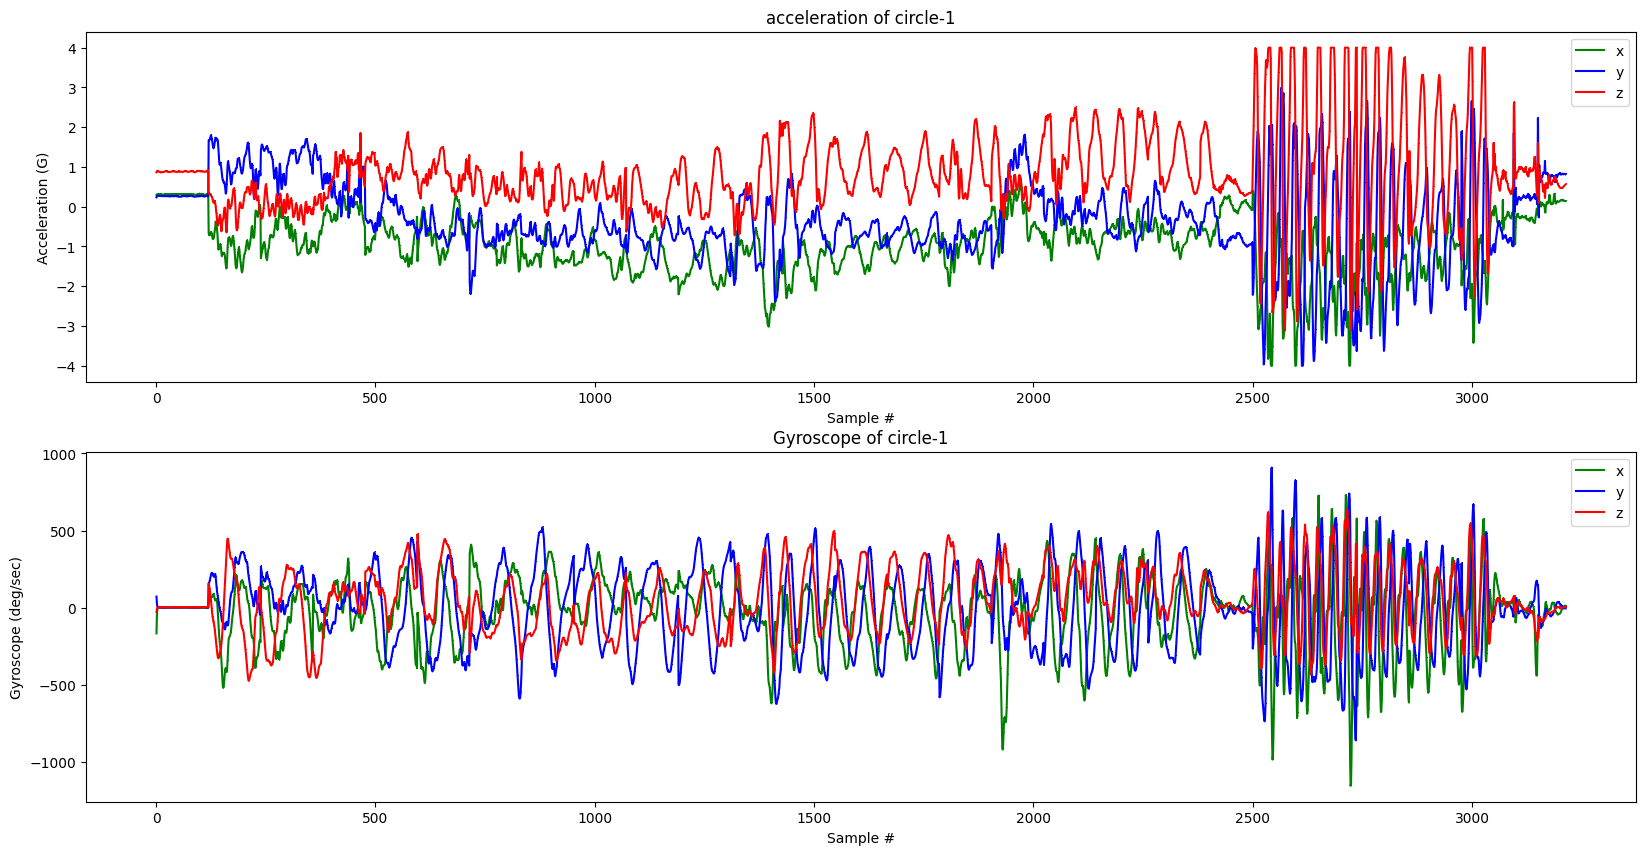

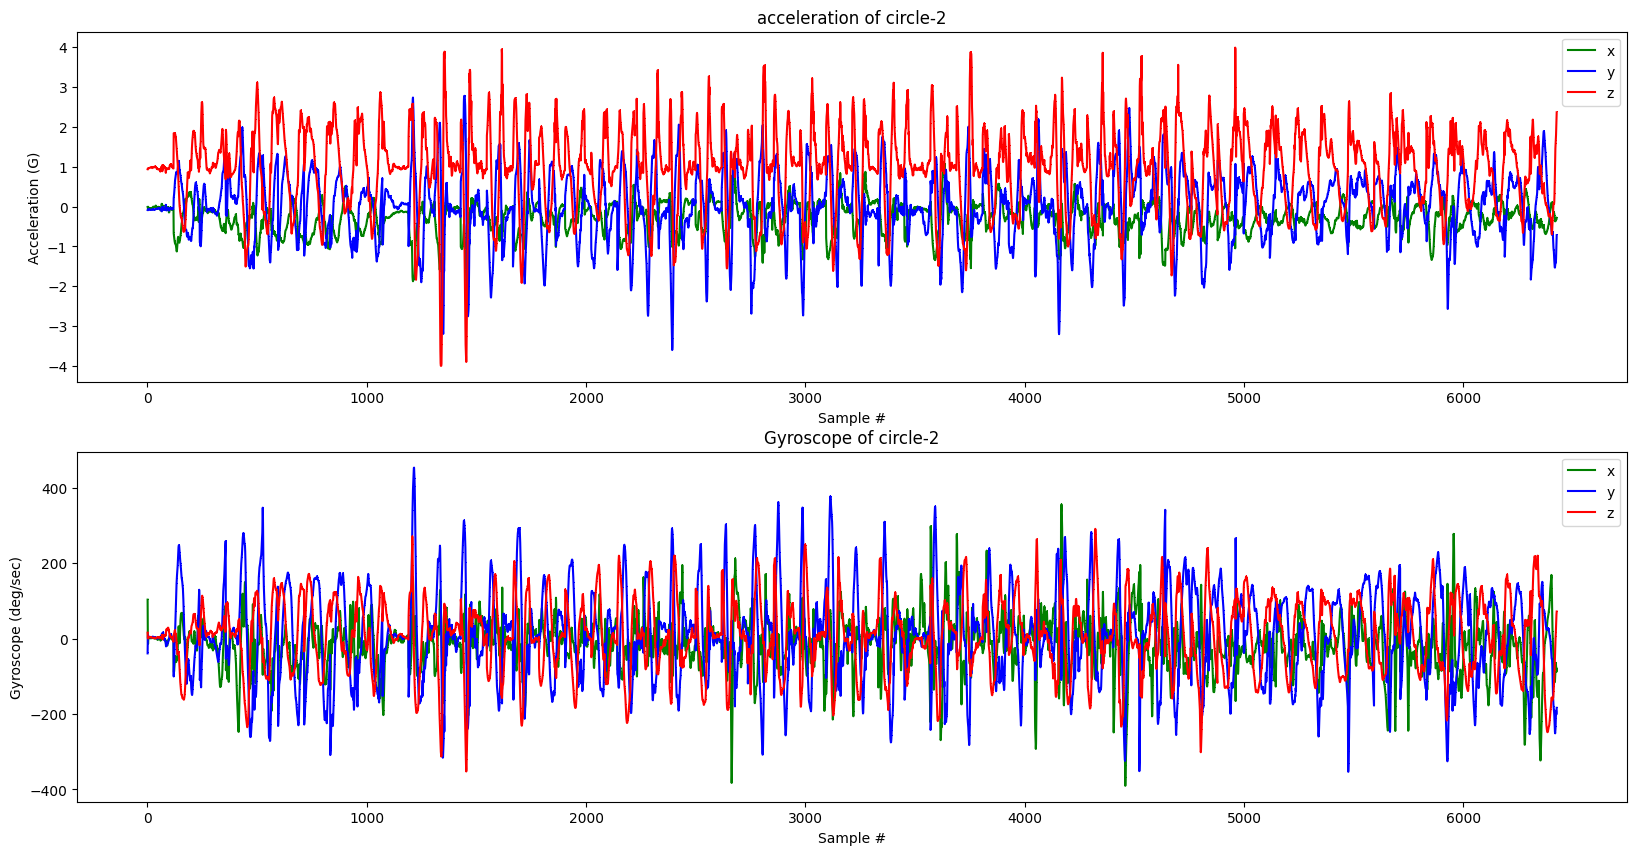

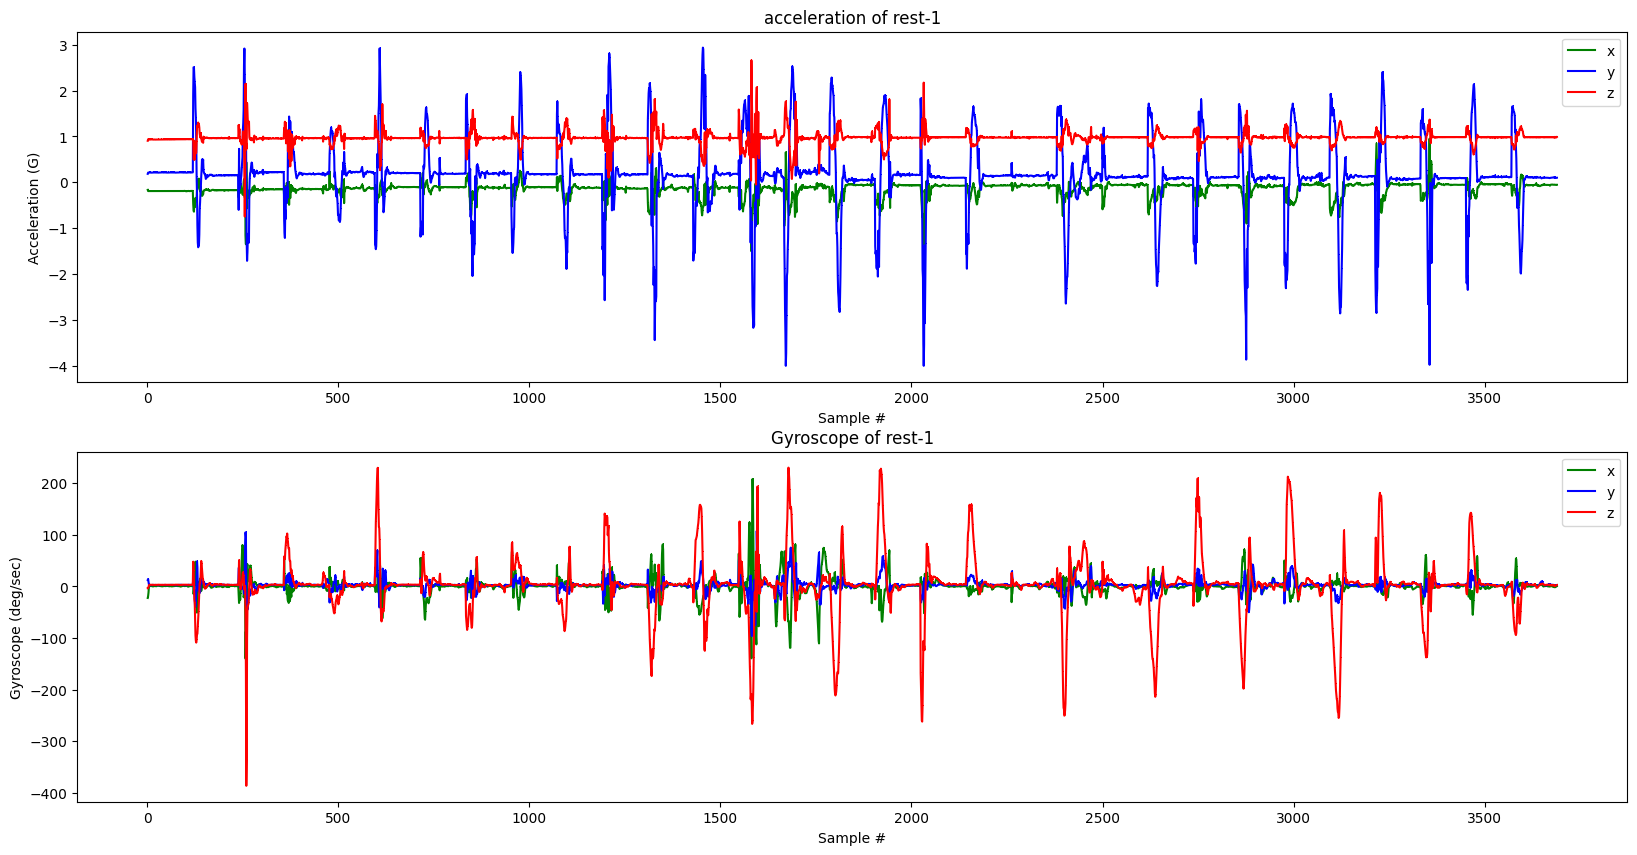

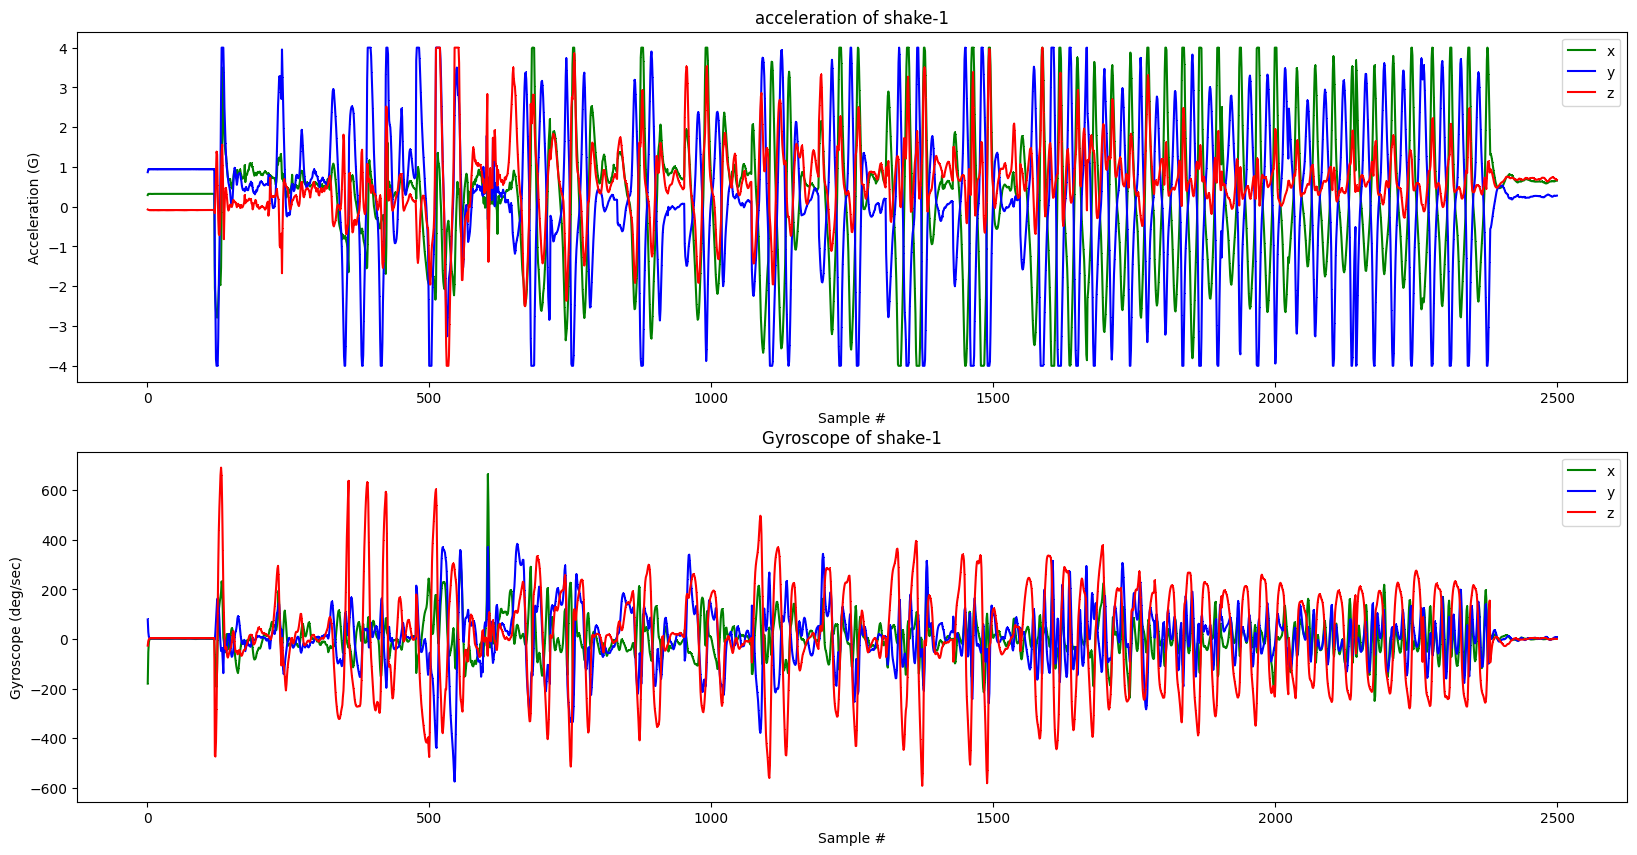

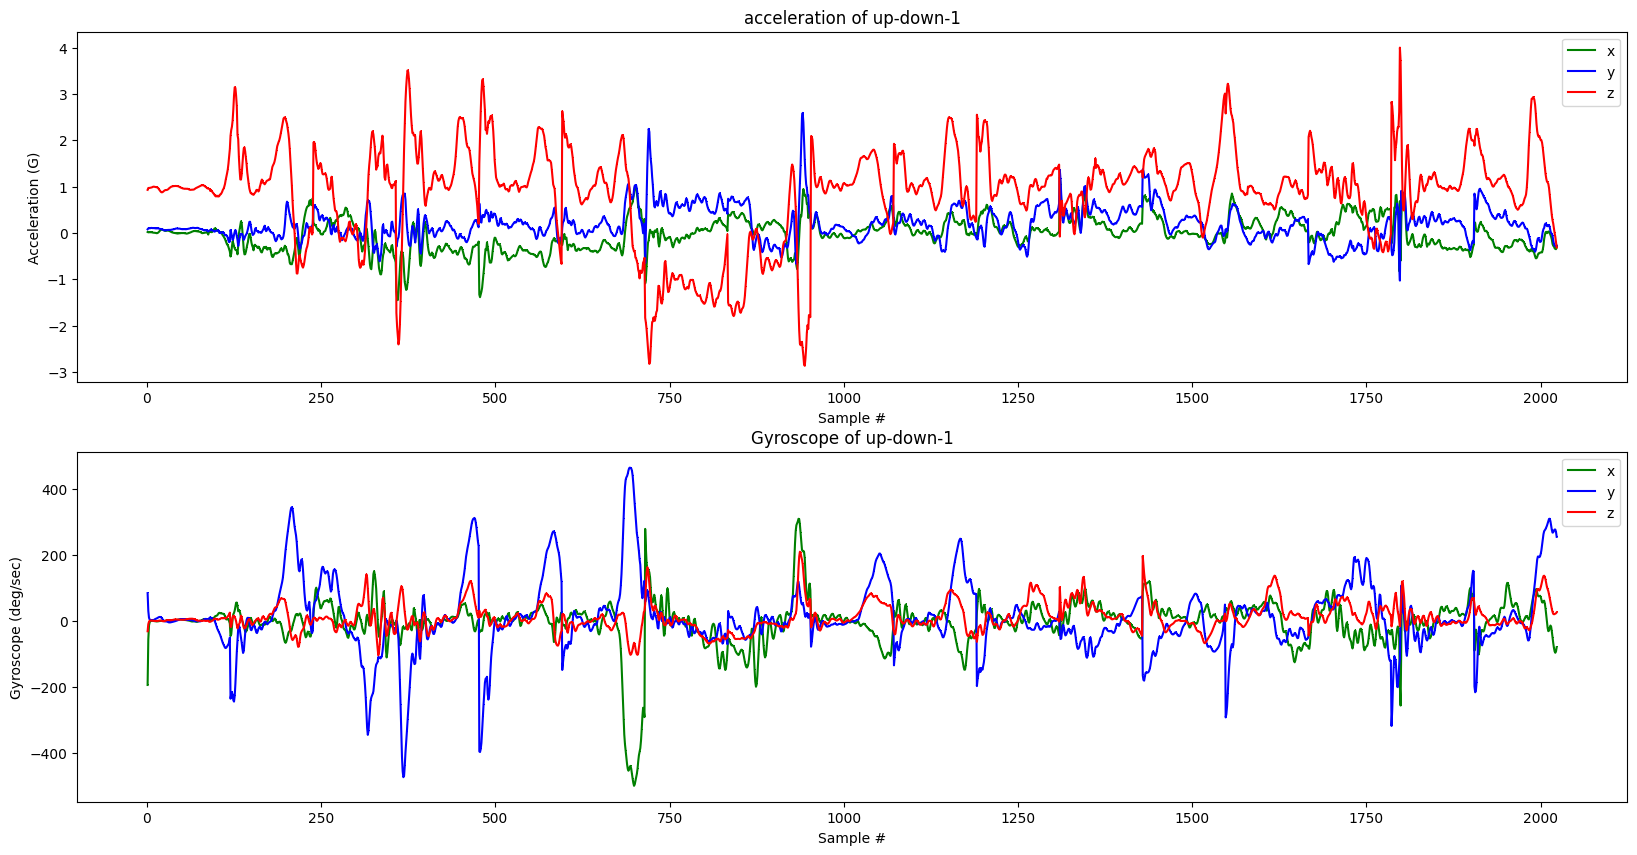

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# the list of gestures that data is available for
GESTURES = [
    "circle-1",
    "circle-2",
    "rest-1",
    "shake-1",
    "up-down-1"
]

for filename in GESTURES :
  name = base_path + filename + ".csv"

  df = pd.read_csv(name)
  
  index = range(1, len(df['aX']) + 1)

  plt.rcParams["figure.figsize"] = (20,10)

  plt.subplot(2, 1, 1)

  plt.plot(index, df['aX'], 'g', label='x', linestyle='solid', marker=',')
  plt.plot(index, df['aY'], 'b', label='y', linestyle='solid', marker=',')
  plt.plot(index, df['aZ'], 'r', label='z', linestyle='solid', marker=',')
  name = "acceleration of " + filename
  plt.title(name)
  plt.xlabel("Sample #")
  plt.ylabel("Acceleration (G)")
  plt.legend()
  # plt.show()
  
  plt.subplot(2, 1, 2)
  plt.plot(index, df['gX'], 'g', label='x', linestyle='solid', marker=',')
  plt.plot(index, df['gY'], 'b', label='y', linestyle='solid', marker=',')
  plt.plot(index, df['gZ'], 'r', label='z', linestyle='solid', marker=',')
  name = "Gyroscope of " + filename
  plt.title(name)
  plt.xlabel("Sample #")
  plt.ylabel("Gyroscope (deg/sec)")
  plt.legend()

  plt.show()


# Extraction of features
We created a function `extract_features` which extract the features in the "window" we are looking at. We grouped the temporal and frequential features goether in a list called `features` of size $7 \times 6 = 42$. Where 7 is the number of features (5 for temporal and 2 for frequential) and 6 for the number of axes : `aX,aY,aZ,gX,gY,gZ` where `a`represents the acceleration and `g`the gyroscope.
Some reminder of formulas we used for different features:  
- The PSD (_Power Spectral Density_) is used here to normalize the power of the signal concerning the size of the frequency bin. The formula is : $PSD(f) = \frac{|f|^2}{Nf_s}$ where $N$ is the length of the signal and $f_s$ is the sampling frequency. We used here 1000hz
- The RMS (Root Mean Squaered) : $RMS = \sqrt{\frac{1}{N} \sum_{i=0}^N x_i^2}$, to simplify in our implementation we used the square-root of the mean which is clearer for the reader.

In [ ]:
def extract_features(window : np.array, drow: bool, gesture: str) -> list :
  fs = 119 # Sampling frequency. TODO : check if it is correct
  features = [] #list of features

  fftArray = []
  psdArray = []
  for axis in window.T :
    
    #time domain
    mean = np.mean(axis)
    std = np.std(axis)
    rms = np.sqrt(np.mean(axis**2))
    minimum = np.min(axis)
    maximum = np.max(axis)

    #frequency domain
    signal_length = len(axis)
    fft = (np.fft.rfft(axis)) #fast fourier transformation (used by psd)

    psd = ((np.abs(fft)**2)/(signal_length*fs)) #power spectral density
    psd_mean = np.mean(psd)
    psd_max = np.max(psd)

    #regroup of the features
    features += [mean,std,rms,minimum,maximum,psd_mean,psd_max]
    
    if drow == True:
      fftArray.append(fft)
      psdArray.append(psd)
    
  if drow == True:
    index = range(1, len(axis) + 1)
    # Create subplots for time domain, FFT, and PSD
    fig, axs = plt.subplots(3, 1, layout='constrained')
    
    axs[0].plot(index, window[:,0], 'g', label='x', linestyle='solid', marker=',')
    axs[0].plot(index, window[:,1], 'b', label='y', linestyle='solid', marker=',')
    axs[0].plot(index, window[:,2], 'r', label='z', linestyle='solid', marker=',')
    name = "Acceleration of " + gesture
    axs[0].set_title(name)
    axs[0].set_xlabel("Time")
    axs[0].set_ylabel("Acceleration (G)")
    axs[0].legend()
    index = range(15)
    axs[1].plot(index, fftArray[0][:15], 'g', label='x', linestyle='solid', marker=',')
    axs[1].plot(index, fftArray[1][:15], 'b', label='y', linestyle='solid', marker=',')
    axs[1].plot(index, fftArray[2][:15], 'r', label='z', linestyle='solid', marker=',')
    name = "FFT of " + gesture
    axs[1].set_title(name)
    axs[1].set_xlabel("Frequency")
    axs[1].set_ylabel("Magnitude")
    axs[1].legend()
    
    index = range(15)
    axs[2].plot(index, psdArray[0][:15], 'g', label='x', linestyle='solid', marker=',')
    axs[2].plot(index, psdArray[1][:15], 'b', label='y', linestyle='solid', marker=',')
    axs[2].plot(index, psdArray[2][:15], 'r', label='z', linestyle='solid', marker=',')
    name = "PSD of " + gesture
    axs[2].set_title(name)
    axs[2].set_xlabel("Frequency")
    axs[2].set_ylabel("Power")
    axs[2].legend()
    plt.show()
    
    
  return features

# def extract_features(window : np.array, print: bool, gesture: str) -> list :
#   fs = 119 # Sampling frequency. TODO : check if it is correct
#   features = [] #list of features
#   if print:
#     print(f"window for gesture '{gesture}': ")
#   for axis in window.T :
#     #time domain
#     print (axis.dtype)
    
#     #regroup of the features
#     features = []
      
#   print("\n")
#   return features

# Train Neural Network





In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

print(f"TensorFlow version = {tf.__version__}\n")

# Set a fixed random seed value, for reproducibility, this will allow us to get
# the same random numbers each time the notebook is run
SEED = 1563
np.random.seed(SEED)
tf.random.set_seed(SEED)

SAMPLES_PER_GESTURE = 119 # Is selected based on the sampling on the Arduino Sketch

NUM_GESTURES = len(GESTURES) #number of gestures we have

# create a one-hot encoded matrix that is used in the output
ONE_HOT_ENCODED_GESTURES = np.eye(NUM_GESTURES)

windows = []  #This will hold the raw data windows for each gesture recording

inputs = []
outputs = []

avg_sampling_intervals = []

# read each csv file and push an input and output

for gesture_index in range(NUM_GESTURES):
  gesture = GESTURES[gesture_index]
  print(f"Processing index {gesture_index} for gesture '{gesture}'.")

  output = ONE_HOT_ENCODED_GESTURES[gesture_index]

  df = pd.read_csv(base_path + gesture + ".csv")

  # Calculate the number of gesture recordings in the file
  num_recordings = int(df.shape[0] / SAMPLES_PER_GESTURE)

  print(f"\tThere are {num_recordings} recordings of the {gesture} gesture.")

  all_deltas = []
  
  
  for i in range(num_recordings):
    window = []
  
    timeWindow = [] # Reset the time window for each individual recording
    
    for j in range(SAMPLES_PER_GESTURE):
        index = i * SAMPLES_PER_GESTURE + j
        
        # Normalize input data:
        # - acceleration range: [-4, +4] -> mapped to [0, 1]
        # - gyroscope range: [-2000, +2000] -> mapped to [0, 1]
        window.append([
            (df['aX'][index] + 4) / 8,
            (df['aY'][index] + 4) / 8,
            (df['aZ'][index] + 4) / 8,
            (df['gX'][index] + 2000) / 4000,
            (df['gY'][index] + 2000) / 4000,
            (df['gZ'][index] + 2000) / 4000
        ])
        # Collect timestamps for the current window
        timeWindow.append(df['millis'][index])

    # Convert to numpy arrays for faster numerical processing
    window = np.array(window)
    time_array = np.array(timeWindow)

    # SAMPLING INTERVAL CALCULATION:
    # np.diff computes the difference between consecutive elements: [t1-t0, t2-t1, ...]
    # This gives us the actual time elapsed between each sample
    deltas = np.diff(time_array)
    all_deltas.extend(deltas)

    # Compute the features for the window
    features = extract_features(window, i == 2 and drawFFT, GESTURES[gesture_index])
    # print(f"\t\tWindow shape: {window.shape}")
    # print(f"\t\tFeatures shape: {len(features)}")
    inputs.append(features)
    outputs.append(output)
    
  # Compute the average sampling period (ms) for this gesture
  if len(all_deltas) > 0:
    avg_period = np.mean(all_deltas)
    avg_sampling_intervals.append(avg_period)
    print(f"\tAverage sampling period for {gesture}: {avg_period:.2f} ms")
    # Calculate Frequency in Hz (1000ms / period_ms)
    print(f"\tFrequency: {1000/avg_period:.2f} Hz")

# Convert the list to numpy array
inputs = np.array(inputs)
outputs = np.array(outputs)


print("Input shape:", inputs.shape)
print("Output shape:", outputs.shape)

print("Data set parsing and preparation complete.")


TensorFlow version = 2.21.0

Processing index 0 for gesture 'circle-1'.
	There are 27 recordings of the circle-1 gesture.
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex128
complex12

## Parse and prepare the data

The next cell parses the csv files and transforms them to a format that will be used to train the Neural Network.
Here we consider a sample of `119`

Update the `GESTURES` list with the gesture data you've collected in `.csv` format.


## Randomize and split the input and output pairs for training

Randomly split input and output pairs into sets of data: 60% for training, 20% for validation, and 20% for testing.

  - the training set is used to train the model
  - the validation set is used to measure how well the model is performing during training
  - the testing set is used to test the model after training

In [6]:
# Randomize the order of the inputs, so they can be evenly distributed for training, testing, and validation
num_inputs = len(inputs)
randomize = np.arange(num_inputs)
np.random.shuffle(randomize)

# Swap the consecutive indexes (0, 1, 2, etc) with the randomized indexes
inputs = inputs[randomize]
outputs = outputs[randomize]

# Split the recordings (group of samples) into three sets: training, testing and validation
TRAIN_SPLIT = int(0.6 * num_inputs) #60% of our datas are for the training here
TEST_SPLIT = int(0.2 * num_inputs + TRAIN_SPLIT) #40% of our datas are for the testing phase

inputs_train, inputs_test, inputs_validate = np.split(inputs, [TRAIN_SPLIT, TEST_SPLIT])
outputs_train, outputs_test, outputs_validate = np.split(outputs, [TRAIN_SPLIT, TEST_SPLIT])

print("Training shape:", inputs_train.shape, outputs_train.shape)
print("Validation shape:", inputs_validate.shape, outputs_validate.shape)
print("Testing shape:", inputs_test.shape, outputs_test.shape)

print("Data set randomization and splitting complete.")

Training shape: (90, 42) (90, 5)
Validation shape: (30, 42) (30, 5)
Testing shape: (30, 42) (30, 5)
Data set randomization and splitting complete.


## Build & Train the Model

We Build and train a [TensorFlow](https://www.tensorflow.org) model using the high-level [Keras](https://www.tensorflow.org/guide/keras) API.
Here

In [7]:
# Build the model and train it
model = tf.keras.Sequential()
print("number of inputs : ", inputs.shape[1])

# We add the input_shape to be more efficient for tensorflow here
# We define it with the number of inputs we computed above (6*7)
model.add(tf.keras.layers.Dense(42, activation='relu',input_shape=(inputs.shape[1],))) # relu is used for performance
model.add(tf.keras.layers.Dense(15, activation='relu'))
model.add(tf.keras.layers.Dense(NUM_GESTURES, activation='softmax')) # softmax is used, because we only expect one gesture to occur per input

# Loss : we use categorical_crossentropy adapted to classification with more than 2 classes
# Metric : accuracy (for the same reason)
# Optimizer : more modern, Adam (Adaptative Moment Estmiation), each weight has his own learning rate adaptative
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

#For the batch_size we changed it by 8 because there is too much noise at 1
#so 8 seems to be a good compromise to have a fast convergence.
history = model.fit(inputs_train, outputs_train, epochs=300, batch_size=8, validation_data=(inputs_validate, outputs_validate))


number of inputs :  42
Epoch 1/300


/home/alanmasu/Documenti/Low-Power_IoT/EMBEDDED-GESTURE-RECO/.venv/lib64/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1774560082.324339  119629 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.1111 - loss: 1.6998 - val_accuracy: 0.1667 - val_loss: 1.6098
Epoch 2/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1889 - loss: 1.6145 - val_accuracy: 0.3333 - val_loss: 1.5740
Epoch 3/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3667 - loss: 1.5740 - val_accuracy: 0.3333 - val_loss: 1.5553
Epoch 4/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3667 - loss: 1.5524 - val_accuracy: 0.3333 - val_loss: 1.5467
Epoch 5/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3667 - loss: 1.5407 - val_accuracy: 0.3333 - val_loss: 1.5388
Epoch 6/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3667 - loss: 1.5321 - val_accuracy: 0.3333 - val_loss: 1.5325
Epoch 7/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3667 - loss: 1.5213 - val_accuracy: 0.3333 - val_loss: 1.5223
Epoch 8/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3667 - loss: 1.5041 - val_accuracy: 0.3333 - val_loss: 1.

## Verify

Graph the models performance vs validation.


### Graph the loss

Graph the loss to see when the model stops improving.

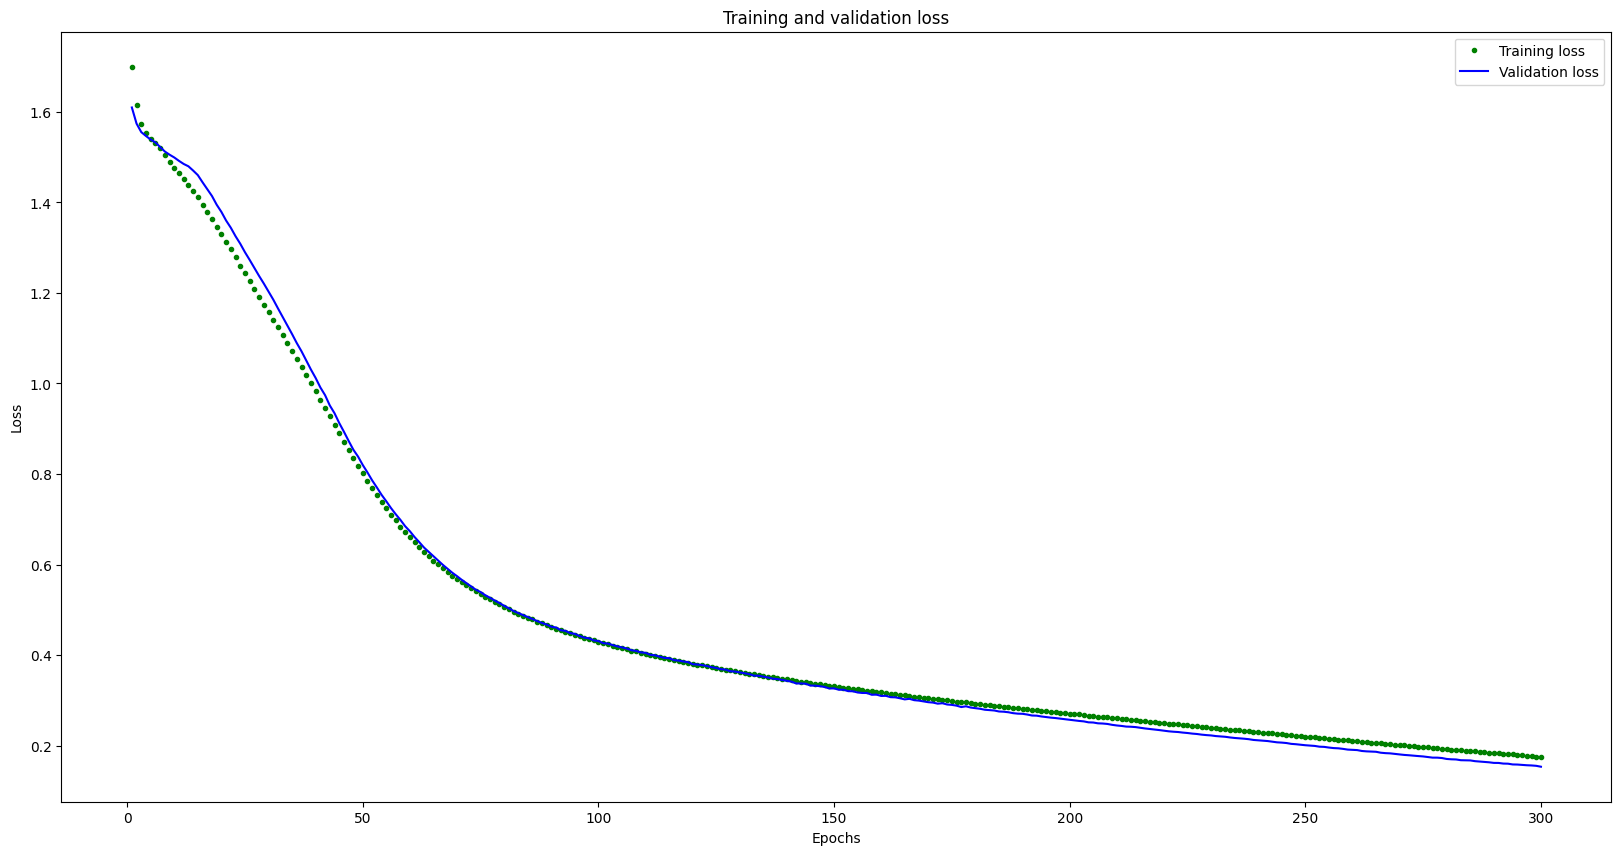

[20.0, 10.0]


In [8]:
# increase the size of the graphs. The default size is (6,4).
plt.rcParams["figure.figsize"] = (20,10)

# graph the loss, the model above is configure to use "mean squared error" as the loss function
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'g.', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

print(plt.rcParams["figure.figsize"])

### Graph the loss again, skipping a bit of the start

We'll graph the same data as the previous code cell, but start at index 100 so we can further zoom in once the model starts to converge.

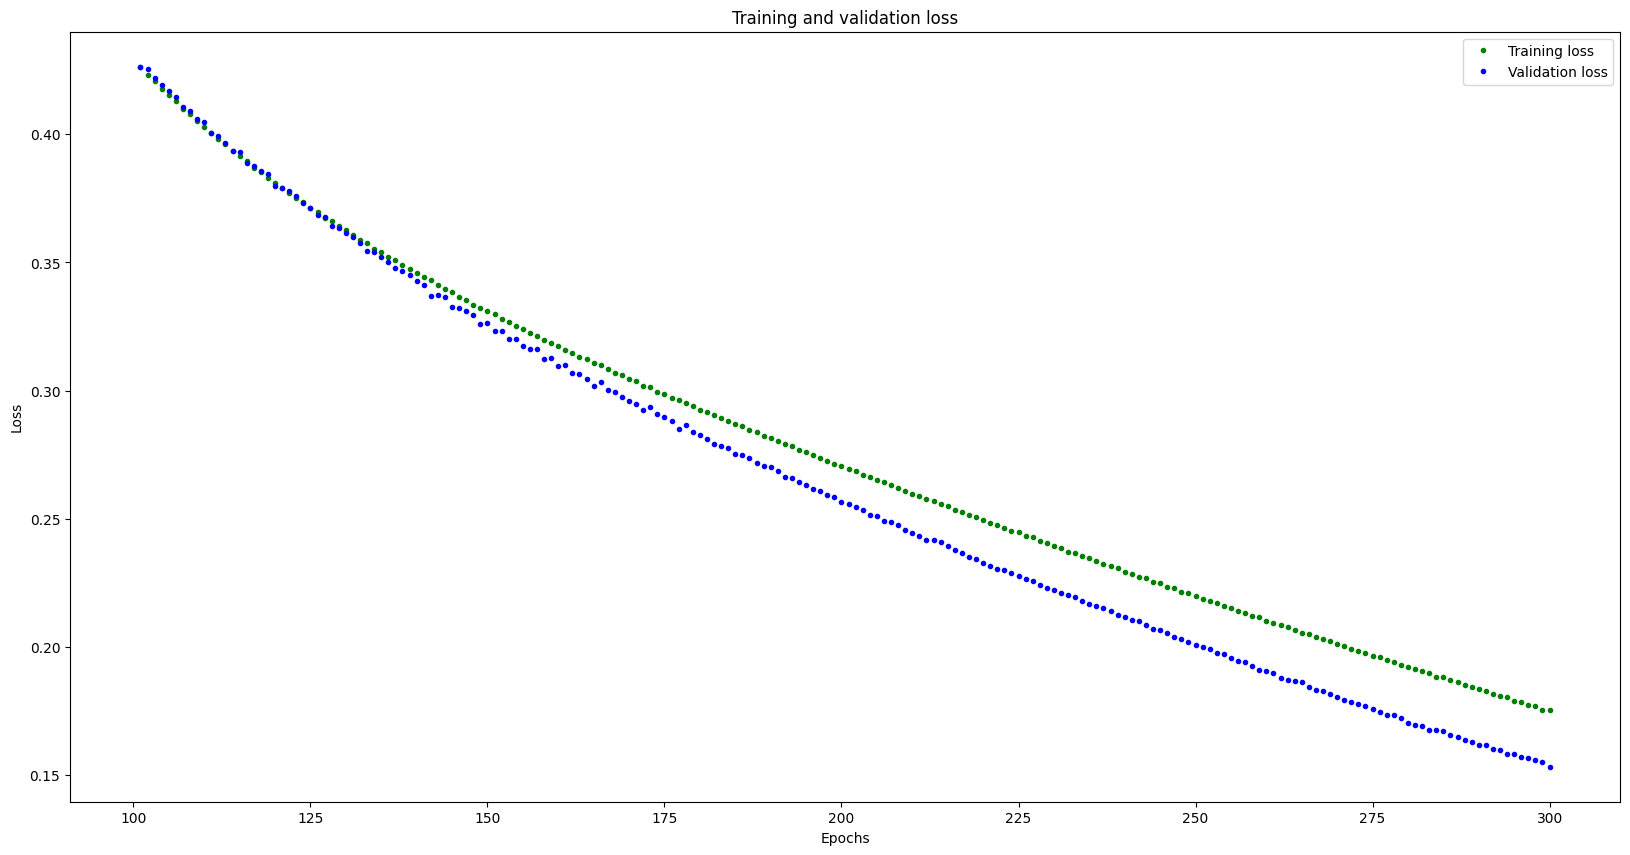

In [9]:
# graph the loss again skipping a bit of the start
SKIP = 100
plt.plot(epochs[SKIP:], loss[SKIP:], 'g.', label='Training loss')
plt.plot(epochs[SKIP:], val_loss[SKIP:], 'b.', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Run with Test Data
Put our test data into the model and plot the predictions


Test accuracy: 0.9333
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9333 - loss: 0.2884
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


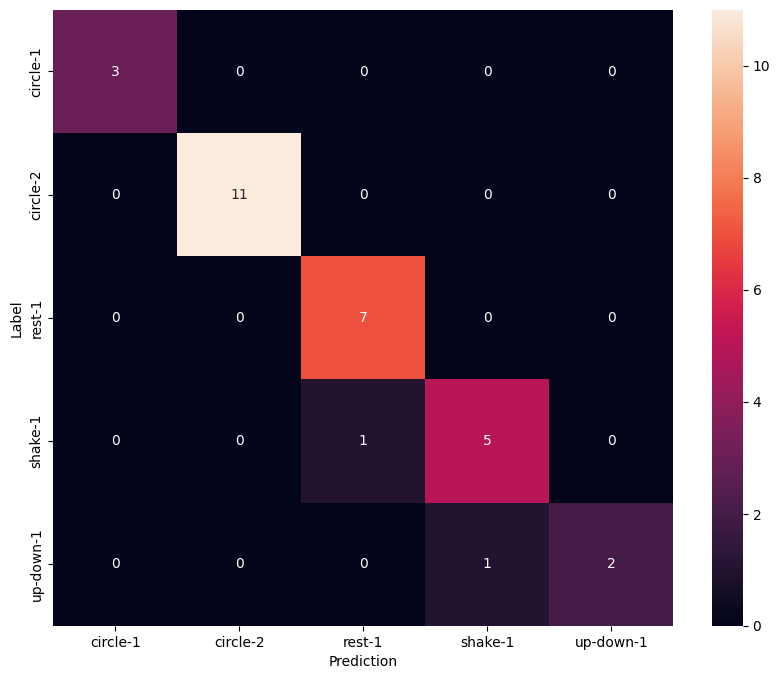

predictions =
 [[0.029 0.648 0.079 0.019 0.225]
 [0.    0.274 0.54  0.184 0.001]
 [0.017 0.704 0.    0.003 0.276]
 [0.291 0.084 0.435 0.08  0.11 ]
 [0.    0.    0.995 0.004 0.   ]
 [0.001 0.98  0.    0.001 0.019]
 [0.015 0.769 0.001 0.004 0.211]
 [0.421 0.077 0.    0.    0.501]
 [0.005 0.874 0.    0.002 0.119]
 [0.001 0.984 0.    0.001 0.014]
 [0.999 0.    0.    0.    0.   ]
 [0.    0.002 0.993 0.005 0.   ]
 [0.028 0.171 0.    0.001 0.799]
 [0.999 0.    0.    0.    0.001]
 [0.    0.006 0.983 0.01  0.001]
 [0.002 0.003 0.    0.994 0.   ]
 [0.    0.985 0.    0.    0.014]
 [0.    0.    0.    1.    0.   ]
 [0.023 0.114 0.631 0.109 0.123]
 [0.005 0.939 0.    0.001 0.054]
 [0.999 0.    0.    0.    0.001]
 [0.    0.    0.    1.    0.   ]
 [0.095 0.052 0.063 0.691 0.099]
 [0.001 0.019 0.96  0.016 0.004]
 [0.    0.    0.    1.    0.   ]
 [0.001 0.985 0.    0.001 0.014]
 [0.002 0.959 0.    0.029 0.01 ]
 [0.001 0.132 0.762 0.096 0.009]
 [0.    0.    0.    1.    0.   ]
 [0.009 0.947 0.    0.004 0.

In [10]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(inputs_test, outputs_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

# use the model to predict the test inputs
predictions = model.predict(inputs_test)

# Convert to class indices
y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(outputs_test, axis=1)

# # use the model to predict the test inputs
model.evaluate(inputs_test, outputs_test)
predictions = model.predict(inputs_test)

# # print the predictions and the expected 


# confusion matrix
confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx,
            xticklabels=GESTURES,
            yticklabels=GESTURES,
            annot=True, fmt='g')
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.show()

# print the predictions and the expected ouputs
print("predictions =\n", np.round(predictions, decimals=3))
print("actual =\n", outputs_test)
print("predicted classes =\n", y_pred)
print("actual classes =\n", y_true)


# Convert the Trained Model to Tensor Flow Lite

The next cell converts the model to TFlite format. The size in bytes of the model is also printed out.

In [11]:
# Check if the output directory exists, if not create it
import os
if not os.path.exists(output_path):
    os.makedirs(output_path)

# Convert the model to the TensorFlow Lite format without quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the model to disk
open(output_path + "gesture_model.tflite", "wb").write(tflite_model)

basic_model_size = os.path.getsize(output_path + "gesture_model.tflite")
print("Model is %d bytes" % basic_model_size)



INFO:tensorflow:Assets written to: /tmp/tmpde0u3g68/assets


INFO:tensorflow:Assets written to: /tmp/tmpde0u3g68/assets


Saved artifact at '/tmp/tmpde0u3g68'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  140046932522384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140046932523536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140046932521424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140046932520848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140046932522576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140046932523728: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model is 12316 bytes


W0000 00:00:1774560104.985855  119629 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1774560104.985867  119629 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1774560104.986062  119629 reader.cc:83] Reading SavedModel from: /tmp/tmpde0u3g68
I0000 00:00:1774560104.986329  119629 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1774560104.986334  119629 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpde0u3g68
I0000 00:00:1774560104.988534  119629 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1774560104.989006  119629 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1774560105.005391  119629 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpde0u3g68
I0000 00:00:1774560105.009996  119629 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 23939 microseconds.
I0000 00:00:1774560105.020041  119629

## Encode the Model in an Arduino Header File

The next cell creates a constant byte array that contains the TFlite model. Import it as a tab with the sketch below.

In [12]:

def convert_tflite_to_header(tflite_path, header_path):
    # Reading the TFLite model file as binary data
    with open(tflite_path, 'rb') as f:
        data = f.read()

    with open(header_path, 'w') as f:
        # Write the header guard and the declaration of the model array
        f.write("const unsigned char model[] = {\n")
        
        # Converting each byte to hexadecimal format (0x00)
        # We put 12 bytes per line to keep the file readable
        hex_lines = []
        for i in range(0, len(data), 12):
            chunk = data[i:i + 12]
            hex_chunk = ", ".join([f"0x{b:02x}" for b in chunk])
            hex_lines.append("  " + hex_chunk)
        
        # Join the lines with a comma and newline
        f.write(",\n".join(hex_lines))
        
        # Close the array
        f.write("\n};\n")

# Conversion
convert_tflite_to_header(output_path + "gesture_model.tflite", output_path + "model.h")

import os
model_h_size = os.path.getsize(output_path + "model.h")
print(f"Header file, model.h, is {model_h_size:,} bytes.")
print("\nOpen the side panel (refresh if needed). Double click model.h to download the file.")

Header file, model.h, is 75,984 bytes.

Open the side panel (refresh if needed). Double click model.h to download the file.
